## Subtração do fundo na curva de luz

In [11]:
import sys
import os
from pathlib import Path

print("1. Bibliotecas importadas.")

# Injeção do caminho absoluto exato para a pasta src
sys.path.append('/home/maju/projeto/LS5039/src') 
from processamento import subtrair_fundo
print("2. Função subtrair_fundo carregada.")

# Parâmetros dinâmicos
ano = "2017"
binagem = "b1h"
energia = "10_30kev" 
obsid = "30201034002A01" 

raios = {
    '2022': {'src': 18.984525, 'bkg': 38.948665},
    '2017': {'src': 20.500000, 'bkg': 40.000000}
}

# Define a raiz do projeto de forma absoluta
project_root = Path("/home/maju/projeto/LS5039")

# Constrói os caminhos injetando as variáveis (Sem a pasta /raw/ e usando _sr.lc)
arq_fonte = project_root / f"/home/maju/projeto/LS5039/data/raw/light_curves/2017/nu30201034002A01_2017_b1h_10_30kev_src.lc"
arq_fundo = project_root / f"/home/maju/projeto/LS5039/data/raw/light_curves/2017/nu30201034002A01_2017_b1h_10_30kev_bk.lc"
arq_saida = project_root / f"data/processed/sub_2017_b1h_10_30.lc"

# Verificação imediata
print(f"3. A verificar ficheiros:\n- Fonte existe? {arq_fonte.exists()}\n- Fundo existe? {arq_fundo.exists()}")

# Garante a criação da pasta de destino
os.makedirs(project_root / "data/processed", exist_ok=True)

# A função Table.read precisa que o caminho seja convertido para string (str)
print("4. A iniciar processamento (Table.read)...")
subtrair_fundo(str(arq_fonte), str(arq_fundo), raios[ano]['src'], raios[ano]['bkg'], str(arq_saida))
print("5. Processamento concluído!")

1. Bibliotecas importadas.
2. Função subtrair_fundo carregada.
3. A verificar ficheiros:
- Fonte existe? True
- Fundo existe? True
4. A iniciar processamento (Table.read)...
Fator de escala de área (a) calculado: 0.2627
Sucesso! Ficheiro corrigido salvo em: /home/maju/projeto/LS5039/data/processed/sub_2017_b1h_10_30.lc

5. Processamento concluído!


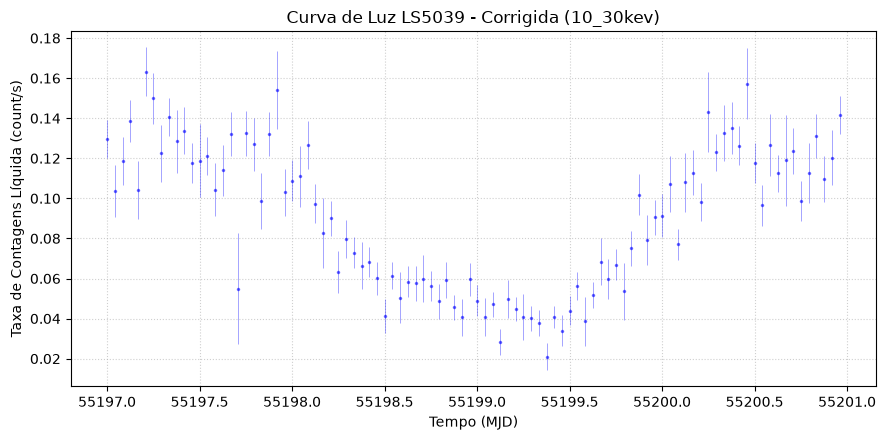

In [13]:
import matplotlib.pyplot as plt
from astropy.table import Table

tabela = Table.read(arq_saida, hdu=1)
df = tabela.to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

plt.figure(figsize=(9, 4.5))
plt.errorbar(df['MJD'], df['RATE'], yerr=df['ERROR'], fmt='b.', alpha=0.5, markersize=3, elinewidth=0.5)

plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens Líquida (count/s)')
plt.title(f'Curva de Luz LS5039 - Corrigida ({energia})')
plt.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

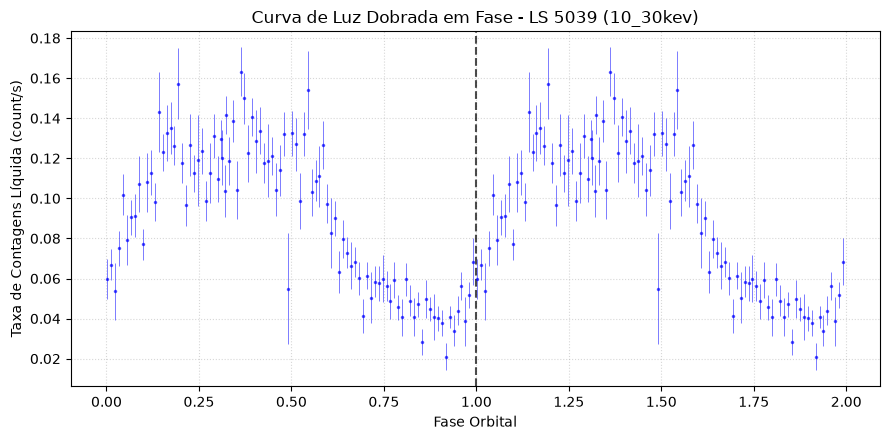

In [15]:
from astropy.table import Table
import matplotlib.pyplot as plt

# A função calcular_fase_orbital deve ser importada junto com subtrair_fundo no topo do notebook

# 1. Carrega os dados e processa a fase
tabela = Table.read(str(arq_saida), hdu=1)
df_completo = calcular_fase_orbital(tabela)

# 2. Visualização
plt.figure(figsize=(9, 4.5))
plt.errorbar(df_completo['FASE'], df_completo['RATE'], yerr=df_completo['ERROR'], 
             fmt='b.', alpha=0.6, markersize=3, elinewidth=0.6)

plt.axvline(1.0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens Líquida (count/s)')
plt.title(f'Curva de Luz Dobrada em Fase - LS 5039 ({energia})')
plt.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

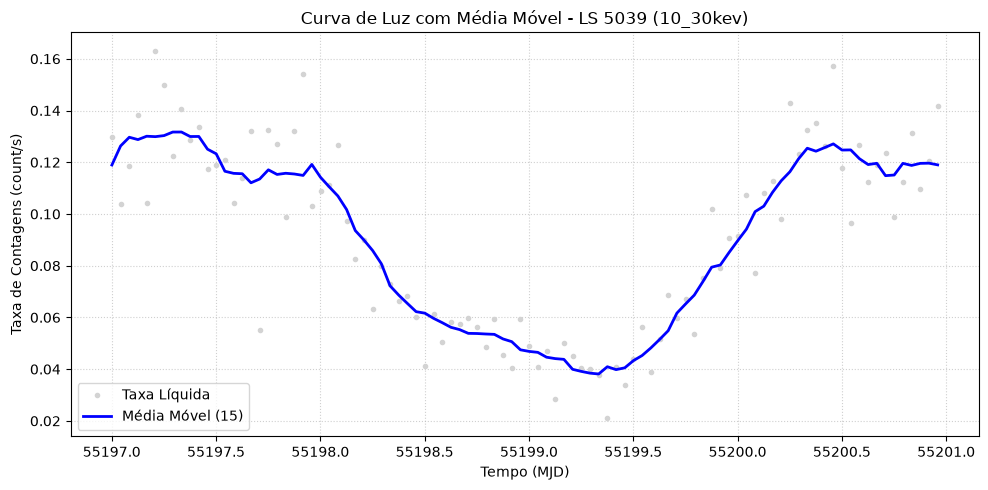

In [18]:
import matplotlib.pyplot as plt
from astropy.table import Table

# 1. Carrega o ficheiro recém-processado em vez de um nome fixo
tabela_suave = Table.read(str(arq_saida), hdu=1)
df_suave = tabela_suave.to_pandas()

# 2. Conversão para MJD
mjd_base = 55197.00076601852
df_suave['MJD'] = mjd_base + (df_suave['TIME'] / 86400.0)

# 3. Cálculo da média móvel (janela de 15 pontos)
df_suave['RATE_SMOOTH'] = df_suave['RATE'].rolling(10, center=True, min_periods=1).mean()

# 4. Visualização
plt.figure(figsize=(10, 5))

# Plota os dados originais e a linha da média móvel
plt.plot(df_suave['MJD'], df_suave['RATE'], '.', color='lightgray', label='Taxa Líquida')
plt.plot(df_suave['MJD'], df_suave['RATE_SMOOTH'], 'b-', linewidth=2, label='Média Móvel (15)')

plt.ticklabel_format(useOffset=False, style='plain')

plt.title(f'Curva de Luz com Média Móvel - LS 5039 ({energia})')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.legend()
plt.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()